# Sprint 2 - Notebook Integrador

Este notebook consume los artefactos del pipeline reproducible del Sprint 2 para revisar:

- `master table` raw y clean
- umbral premium fijo basado en `dev`
- features generadas
- experimentos de seleccion de variables
- set final seleccionado


In [34]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

cwd = Path.cwd().resolve()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "sprint_02"


In [35]:
master_raw = pd.read_parquet(INTERIM_DIR / "01_master_table_raw_sprint2.parquet")
master_clean = pd.read_parquet(PROCESSED_DIR / "03_master_table_clean.parquet")
features_rfm = pd.read_parquet(PROCESSED_DIR / "05_features_rfm.parquet")
features_selected = pd.read_parquet(PROCESSED_DIR / "06_features_selected.parquet")
threshold_meta = json.loads((PROCESSED_DIR / "premium_threshold_dev.json").read_text())
selection_meta = json.loads((PROCESSED_DIR / "06_feature_selection_experiments.json").read_text())
selection_results = pd.read_parquet(PROCESSED_DIR / "06_feature_selection_experiments.parquet")
evaluation_meta = json.loads((PROCESSED_DIR / "08_evaluation_metrics.json").read_text())


## 1. Estado de artefactos


In [36]:
artifact_summary = pd.DataFrame([
    {"artifact": "master_raw", "rows": master_raw.shape[0], "cols": master_raw.shape[1]},
    {"artifact": "master_clean", "rows": master_clean.shape[0], "cols": master_clean.shape[1]},
    {"artifact": "features_rfm", "rows": features_rfm.shape[0], "cols": features_rfm.shape[1]},
    {"artifact": "features_selected", "rows": features_selected.shape[0], "cols": features_selected.shape[1]},
])
artifact_summary


,artifact,rows,cols
0,master_raw,96096,32
1,master_clean,96096,33
2,features_rfm,96096,51
3,features_selected,96096,30


## 2. Umbral premium fijo


In [37]:
threshold_meta


{'profile_source': 'dev',
 'premium_threshold': 197.01,
 'threshold_rule': 'P80',
 'threshold_reference_population': 'data/splits/temporal_2018q4/dev',
 'threshold_mode': 'apply'}

In [38]:
pd.Series({
    "premium_rate": master_clean["is_premium"].mean(),
    "min_premium_total_spent": master_clean.loc[master_clean["is_premium"].eq(1), "total_spent"].min(),
    "max_non_premium_total_spent": master_clean.loc[master_clean["is_premium"].eq(0), "total_spent"].max(),
})


premium_rate                     0.200008
min_premium_total_spent        197.010000
max_non_premium_total_spent    197.000000
dtype: float64

## 3. Calidad de la master table raw


In [39]:
raw_profile = pd.DataFrame({
    "dtype": master_raw.dtypes.astype(str),
    "nulls": master_raw.isna().sum(),
    "null_pct": (master_raw.isna().mean() * 100).round(2),
    "n_unique": master_raw.nunique(dropna=True),
}).sort_values(["null_pct", "nulls"], ascending=False)
raw_profile.head(15)


,dtype,nulls,null_pct,n_unique
avg_delivery_days,float64,8884,9.24,245
avg_ticket,float64,8883,9.24,27317
total_spent,float64,8882,9.24,27163
avg_order_price,float64,8882,9.24,8369
avg_freight_value,float64,8882,9.24,8664
avg_freight_ratio,float64,8882,9.24,41587
top_category,str,8205,8.54,73
avg_review_score,float64,6966,7.25,35
max_item_price,float64,6914,7.19,5528
avg_item_price,float64,6914,7.19,7795


## 4. Features creadas


In [40]:
new_feature_cols = [c for c in features_rfm.columns if c not in master_clean.columns]
new_feature_cols


['items_per_order',
 'products_per_order',
 'max_to_avg_price_ratio',
 'freight_to_item_ratio',
 'installments_gt_1_flag',
 'installments_gt_6_flag',
 'credit_card_flag',
 'boleto_flag',
 'voucher_flag',
 'payment_complexity_flag',
 'has_late_delivery',
 'has_cancellation',
 'delivery_gap',
 'reviews_per_order',
 'region_group',
 'far_region_flag',
 'top_category_group',
 'top_category_is_high_value']

In [41]:
features_rfm[new_feature_cols + ["is_premium"]].head(10)


,items_per_order,products_per_order,max_to_avg_price_ratio,freight_to_item_ratio,installments_gt_1_flag,installments_gt_6_flag,credit_card_flag,boleto_flag,voucher_flag,payment_complexity_flag,has_late_delivery,has_cancellation,delivery_gap,reviews_per_order,region_group,far_region_flag,top_category_group,top_category_is_high_value,is_premium
0,1.0,1.0,1.0,0.175054,1,0,1,0,0,0,0,0,11.0,1.0,southeast,0,moveis_escritorio,1,0
1,1.0,1.0,1.0,0.160830,1,1,1,0,0,1,0,0,8.0,1.0,southeast,0,utilidades_domesticas,0,1
2,1.0,1.0,1.0,0.127126,1,1,1,0,0,1,1,0,-2.0,1.0,southeast,0,moveis_escritorio,1,0
3,1.0,1.0,1.0,0.155796,0,0,1,0,0,0,0,0,13.0,1.0,southeast,0,moveis_escritorio,1,0
4,1.0,1.0,1.0,0.096739,1,1,1,0,0,1,0,0,5.0,1.0,southeast,0,other,0,1
5,1.0,1.0,1.0,0.519013,0,0,1,0,0,0,0,0,12.0,1.0,southeast,0,informatica_acessorios,0,0
6,1.0,1.0,1.0,0.809548,1,0,1,0,0,0,0,0,11.0,1.0,southeast,0,other,0,0
7,1.0,1.0,1.0,0.225926,0,0,1,0,0,0,0,0,22.0,1.0,southeast,0,moveis_decoracao,0,0
8,1.0,1.0,1.0,0.596838,0,0,1,0,0,0,0,0,11.0,1.0,southeast,0,automotivo,0,0
9,1.0,1.0,1.0,0.178830,0,0,1,0,0,0,0,0,7.0,1.0,southeast,0,informatica_acessorios,0,0


## 5. Experimentos de seleccion


In [42]:
selection_results[["experiment", "method", "threshold", "n_features", "auc_train", "auc_val", "gini_train", "gini_val"]]


,experiment,method,threshold,n_features,auc_train,auc_val,gini_train,gini_val
0,initial,initial,NaN,37,0.817191,0.793878,0.634383,0.587757
1,missing_le_0.10,missing,0.10,37,0.817191,0.793878,0.634383,0.587757
2,corr_le_0.90,correlation,0.90,29,0.815225,0.792280,0.630450,0.584561
3,corr_le_0.95,correlation,0.95,32,0.816992,0.792225,0.633984,0.584450
4,corr_le_0.85,correlation,0.85,28,0.817210,0.792146,0.634420,0.584292
5,univariate_top_30pct,univariate,0.30,12,0.794086,0.775163,0.588171,0.550326
6,univariate_top_20pct,univariate,0.20,8,0.787158,0.768623,0.574316,0.537247
7,univariate_top_10pct,univariate,0.10,4,0.745188,0.742980,0.490377,0.485961


In [43]:
selection_meta


{'input_path': '/var/www/codigo/maestria_ia/umsa/mod_13/miadas_mod_13_scrum/data/processed/05_features_rfm.parquet',
 'validation_cutoff': '2018-07-01',
 'max_train_rows': 30000,
 'base_feature_count': 37,
 'best_experiment': 'corr_le_0.85',
 'best_feature_count': 28,
 'best_features': ['total_orders',
  'total_items',
  'total_products',
  'avg_review_score',
  'avg_delivery_days',
  'avg_estimated_delivery_days',
  'delivered_orders',
  'late_deliveries',
  'payment_methods_count',
  'max_payment_installments',
  'recency_days',
  'customer_lifetime_days',
  'cancellation_rate',
  'products_per_order',
  'max_to_avg_price_ratio',
  'installments_gt_1_flag',
  'installments_gt_6_flag',
  'credit_card_flag',
  'voucher_flag',
  'delivery_gap',
  'reviews_per_order',
  'far_region_flag',
  'top_category_is_high_value',
  'customer_state',
  'main_payment_type',
  'top_category',
  'region_group',
  'top_category_group'],
 'mandatory_exclude': ['customer_unique_id',
  'is_premium',
  'to

## 6. Set final seleccionado


In [44]:
best_row = selection_results.loc[selection_results["experiment"].eq(selection_meta["best_experiment"])].iloc[0]
pd.Series({
    "best_experiment": selection_meta["best_experiment"],
    "best_feature_count": selection_meta["best_feature_count"],
    "auc_train": best_row["auc_train"],
    "auc_val": best_row["auc_val"],
    "gini_train": best_row["gini_train"],
    "gini_val": best_row["gini_val"],
    "selected_dataset_rows": features_selected.shape[0],
    "selected_dataset_cols": features_selected.shape[1],
})


best_experiment          corr_le_0.85
best_feature_count                 28
auc_train                     0.81721
auc_val                      0.792146
gini_train                    0.63442
gini_val                     0.584292
selected_dataset_rows           96096
selected_dataset_cols              30
dtype: object

In [45]:
selection_meta["best_features"]


['total_orders',
 'total_items',
 'total_products',
 'avg_review_score',
 'avg_delivery_days',
 'avg_estimated_delivery_days',
 'delivered_orders',
 'late_deliveries',
 'payment_methods_count',
 'max_payment_installments',
 'recency_days',
 'customer_lifetime_days',
 'cancellation_rate',
 'products_per_order',
 'max_to_avg_price_ratio',
 'installments_gt_1_flag',
 'installments_gt_6_flag',
 'credit_card_flag',
 'voucher_flag',
 'delivery_gap',
 'reviews_per_order',
 'far_region_flag',
 'top_category_is_high_value',
 'customer_state',
 'main_payment_type',
 'top_category',
 'region_group',
 'top_category_group']

## 7. Evaluacion vs baseline


In [46]:
metrics_compare = pd.DataFrame([
    {"metric": "precision", "baseline_s1": evaluation_meta["baseline_metrics"]["precision"], "sprint2_val": evaluation_meta["validation_metrics"]["precision"]},
    {"metric": "recall", "baseline_s1": evaluation_meta["baseline_metrics"]["recall"], "sprint2_val": evaluation_meta["validation_metrics"]["recall"]},
    {"metric": "f1", "baseline_s1": evaluation_meta["baseline_metrics"]["f1"], "sprint2_val": evaluation_meta["validation_metrics"]["f1"]},
    {"metric": "roc_auc", "baseline_s1": evaluation_meta["baseline_metrics"]["roc_auc"], "sprint2_val": evaluation_meta["validation_metrics"]["roc_auc"]},
    {"metric": "gini", "baseline_s1": evaluation_meta["baseline_metrics"]["gini"], "sprint2_val": evaluation_meta["validation_metrics"]["gini"]},
])
metrics_compare


,metric,baseline_s1,sprint2_val
0,precision,0.3000,0.476571
1,recall,0.1600,0.629395
2,f1,0.2100,0.542424
3,roc_auc,0.5355,0.792918
4,gini,0.0710,0.585835


In [47]:
evaluation_meta["validation_metrics"]


{'precision': 0.47657082002129925,
 'recall': 0.629395218002813,
 'f1': 0.5424242424242425,
 'roc_auc': 0.7929175120696635,
 'gini': 0.5858350241393271,
 'confusion_matrix': [[3825, 983], [527, 895]],
 'roc_curve': {'fpr': [0.0,
   0.0,
   0.0,
   0.00020798668885191348,
   0.00020798668885191348,
   0.0006239600665557404,
   0.0006239600665557404,
   0.0010399334442595673,
   0.0010399334442595673,
   0.0012479201331114808,
   0.0012479201331114808,
   0.0014559068219633944,
   0.0014559068219633944,
   0.0016638935108153079,
   0.0016638935108153079,
   0.0018718801996672214,
   0.0018718801996672214,
   0.0020798668885191347,
   0.0020798668885191347,
   0.0024958402662229617,
   0.0024958402662229617,
   0.0027038269550748754,
   0.0027038269550748754,
   0.0029118136439267887,
   0.0029118136439267887,
   0.003119800332778702,
   0.003119800332778702,
   0.0033277870216306157,
   0.0033277870216306157,
   0.003535773710482529,
   0.003535773710482529,
   0.0037437603993344427,
   

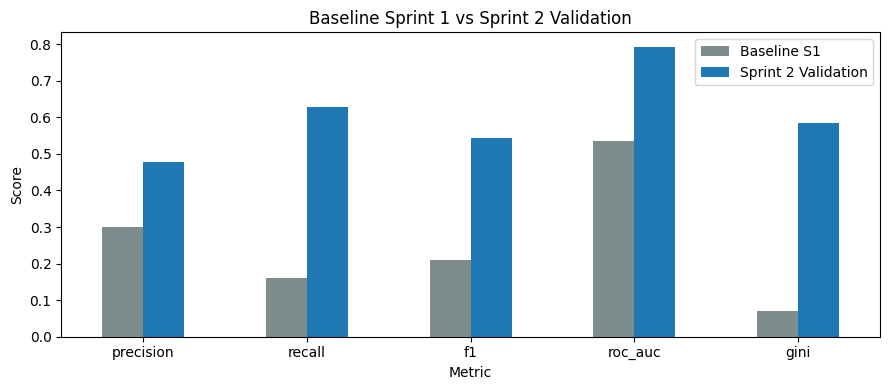

In [48]:
plot_df = metrics_compare.set_index("metric")
ax = plot_df.plot(kind="bar", figsize=(9, 4), color=["#7f8c8d", "#1f77b4"])
ax.set_title("Baseline Sprint 1 vs Sprint 2 Validation")
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.legend(["Baseline S1", "Sprint 2 Validation"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


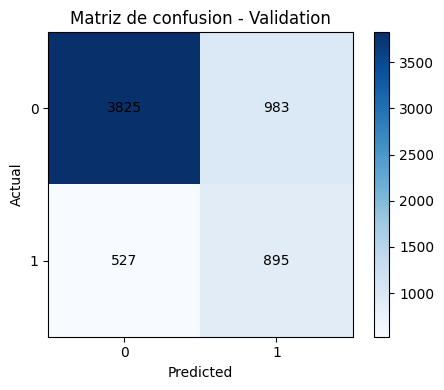

In [49]:
cm = evaluation_meta["validation_metrics"]["confusion_matrix"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusion - Validation")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 8. Curva ROC de validation


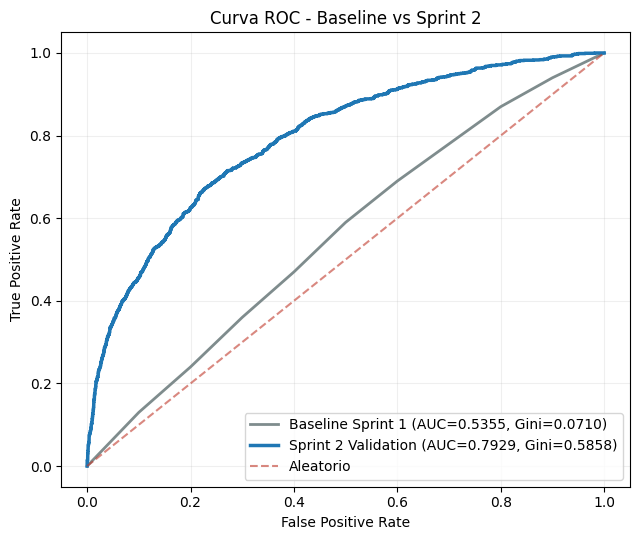

In [50]:
roc_data = evaluation_meta["validation_metrics"]["roc_curve"]
fpr = roc_data["fpr"]
tpr = roc_data["tpr"]
auc_val = evaluation_meta["validation_metrics"]["roc_auc"]
gini_val = evaluation_meta["validation_metrics"]["gini"]

# Curva de referencia usada en la presentacion de Sprint 1 para el baseline
baseline_fpr = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
baseline_tpr = [0.0, 0.13, 0.24, 0.36, 0.47, 0.59, 0.69, 0.78, 0.87, 0.94, 1.0]
baseline_auc = evaluation_meta["baseline_metrics"]["roc_auc"]
baseline_gini = evaluation_meta["baseline_metrics"]["gini"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(baseline_fpr, baseline_tpr, label=f"Baseline Sprint 1 (AUC={baseline_auc:.4f}, Gini={baseline_gini:.4f})", color="#7f8c8d", linewidth=2)
ax.plot(fpr, tpr, label=f"Sprint 2 Validation (AUC={auc_val:.4f}, Gini={gini_val:.4f})", color="#1f77b4", linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle="--", color="#c0392b", alpha=0.6, label="Aleatorio")
ax.set_title("Curva ROC - Baseline vs Sprint 2")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
